# U-Net Training Analysis
**Brainhack School 2026**

---
This notebook analyzes the training history of the U-Net model trained for MRI k-space artifact correction.

### Contents
1. Load training history
2. Loss curves (train / val)
3. SSIM and PSNR curves
4. Metrics summary table
5. Learning rate schedule
6. Training speed analysis

## 1. Imports & configuration

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.titlesize']   = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Paths ─────────────────────────────────────────────────────────
RESULTS_DIR  = Path('/Users/annaellesarrazin/Sarrazin_project/results')
HISTORY_PATH = RESULTS_DIR / 'training_history.csv'

df = pd.read_csv(HISTORY_PATH)
print(f'Epochs loaded : {len(df)}')
print(df.to_string(index=False))

Epochs loaded : 20
 epoch  train_loss  val_loss  val_SSIM  val_PSNR       lr  time_s
     1     0.00143   0.00060    0.4381     20.87 0.000994  5172.3
     2     0.00063   0.00058    0.5059     21.33 0.000976  5182.4
     3     0.00058   0.00055    0.5496     22.27 0.000946  5129.6
     4     0.00056   0.00053    0.5935     23.02 0.000905  5170.0
     5     0.00056   0.00052    0.5816     23.03 0.000854  5172.7
     6     0.00054   0.00051    0.5907     23.14 0.000794  5155.8
     7     0.00053   0.00050    0.6080     23.48 0.000727  5159.6
     8     0.00052   0.00049    0.6173     23.66 0.000655  5136.9
     9     0.00051   0.00049    0.6220     23.80 0.000579  5201.3
    10     0.00050   0.00048    0.6221     23.88 0.000500  5169.2
    11     0.00050   0.00048    0.6297     23.99 0.000422  5286.5
    12     0.00049   0.00048    0.6302     24.04 0.000346  5101.0
    13     0.00049   0.00048    0.6283     24.06 0.000274  5226.0
    14     0.00049   0.00048    0.6302     24.02 0.000207

## 2. Loss curves — Train vs Validation

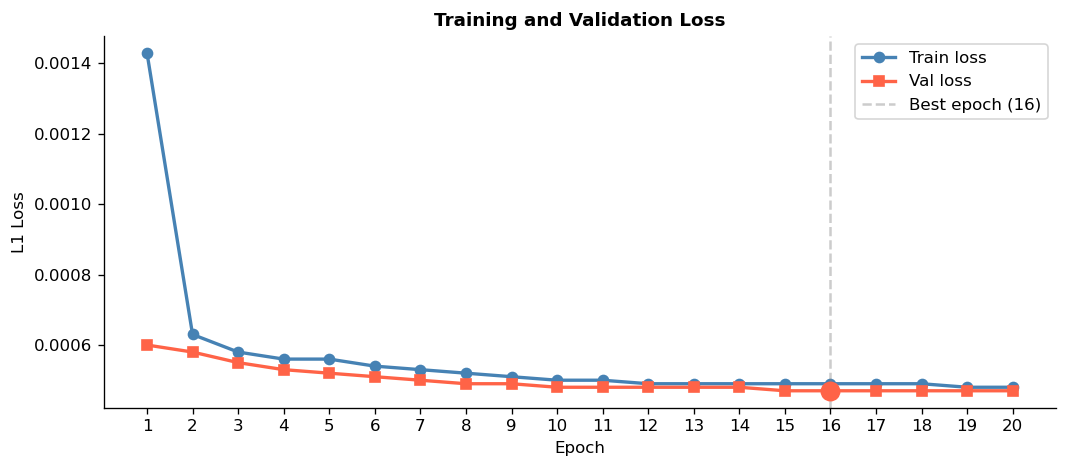

Best val_loss = 0.00047 at epoch 16


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df['epoch'], df['train_loss'], 'o-', label='Train loss', color='steelblue', linewidth=2)
ax.plot(df['epoch'], df['val_loss'],   's-', label='Val loss',   color='tomato',    linewidth=2)

# Mark best epoch
best_val_loss_val = df['val_loss'].min()
best_epoch = df[df['val_loss'] == best_val_loss_val].loc[
    lambda x: x['val_SSIM'].idxmax()
]

ax.axvline(best_epoch['epoch'], color='gray', linestyle='--', alpha=0.4, 
           label=f'Best epoch ({int(best_epoch["epoch"])})')
ax.scatter(best_epoch['epoch'], best_epoch['val_loss'], color='tomato', s=120, zorder=5)

ax.set_xlabel('Epoch')
ax.set_ylabel('L1 Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.set_xticks(df['epoch'])
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val_loss = {best_epoch["val_loss"]:.5f} at epoch {int(best_epoch["epoch"])}')

## 3. SSIM and PSNR curves

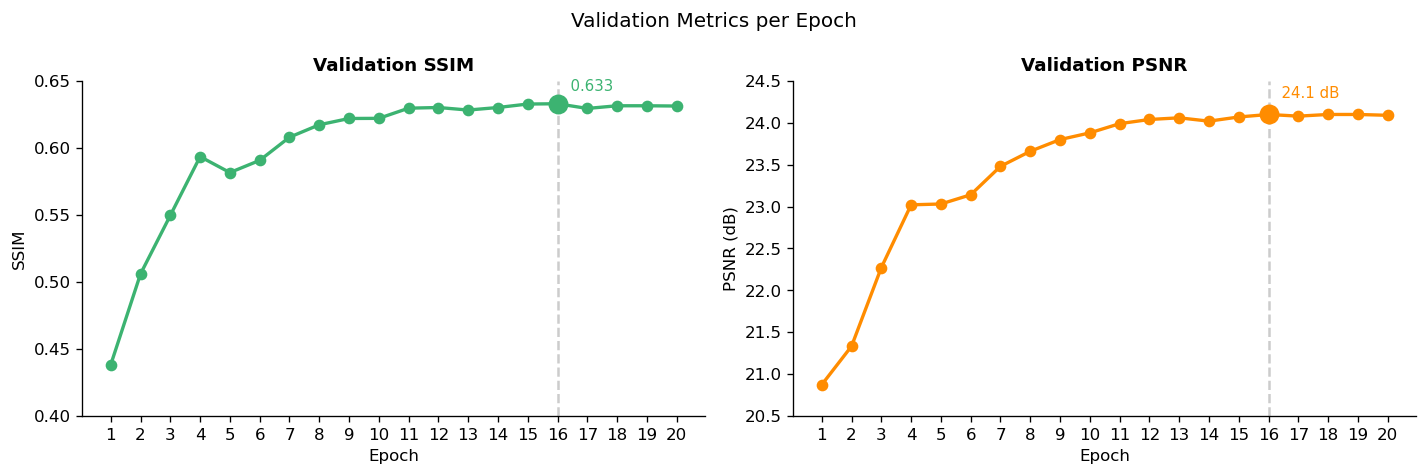

Best SSIM = 0.633 at epoch 16
Best PSNR = 24.1 dB at epoch 16


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SSIM
axes[0].plot(df['epoch'], df['val_SSIM'], 'o-', color='mediumseagreen', linewidth=2)
axes[0].axvline(best_epoch['epoch'], color='gray', linestyle='--', alpha=0.4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('SSIM')
axes[0].set_title('Validation SSIM')
axes[0].set_xticks(df['epoch'])
axes[0].set_ylim(0.4, 0.65)

# Annotate best SSIM
best_ssim = df.loc[df['val_SSIM'].idxmax()]
axes[0].scatter(best_ssim['epoch'], best_ssim['val_SSIM'], color='mediumseagreen', s=120, zorder=5)
axes[0].annotate(f"  {best_ssim['val_SSIM']:.3f}",
                 (best_ssim['epoch'], best_ssim['val_SSIM']),
                 (best_ssim['epoch'] + 0.1, best_ssim['val_SSIM'] + 0.01),
                 fontsize=9, color='mediumseagreen')

# PSNR
axes[1].plot(df['epoch'], df['val_PSNR'], 'o-', color='darkorange', linewidth=2)
axes[1].axvline(best_epoch['epoch'], color='gray', linestyle='--', alpha=0.4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Validation PSNR')
axes[1].set_xticks(df['epoch'])
axes[1].set_ylim(20.5, 24.5)

# Annotate best PSNR
best_psnr = df.loc[df['val_PSNR'].idxmax()]
axes[1].scatter(best_psnr['epoch'], best_psnr['val_PSNR'], color='darkorange', s=120, zorder=5)
axes[1].annotate(f"  {best_psnr['val_PSNR']:.1f} dB",
                 (best_psnr['epoch'], best_psnr['val_PSNR']),
                 (best_psnr['epoch'] + 0.1, best_psnr['val_PSNR'] + 0.2),
                 fontsize=9, color='darkorange')

fig.suptitle('Validation Metrics per Epoch', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metrics_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best SSIM = {best_ssim["val_SSIM"]:.3f} at epoch {int(best_ssim["epoch"])}')
print(f'Best PSNR = {best_psnr["val_PSNR"]:.1f} dB at epoch {int(best_psnr["epoch"])}')

## 4. Metrics summary table

In [18]:
summary = pd.DataFrame({
    'Metric': ['Best val_loss', 'Best val_SSIM', 'Best val_PSNR',
               'Final train_loss', 'Final val_loss'],
    'Value':  [
        f"{df['val_loss'].min():.5f}  (epoch {df['val_loss'].idxmin()+1})",
        f"{df['val_SSIM'].max():.3f}  (epoch {df['val_SSIM'].idxmax()+1})",
        f"{df['val_PSNR'].max():.1f} dB  (epoch {df['val_PSNR'].idxmax()+1})",
        f"{df['train_loss'].iloc[-1]:.5f}",
        f"{df['val_loss'].iloc[-1]:.5f}",
    ]
})
print(summary.to_string(index=False))

          Metric               Value
   Best val_loss 0.00047  (epoch 15)
   Best val_SSIM   0.633  (epoch 16)
   Best val_PSNR 24.1 dB  (epoch 16)
Final train_loss             0.00048
  Final val_loss             0.00047


## 5. Learning rate schedule

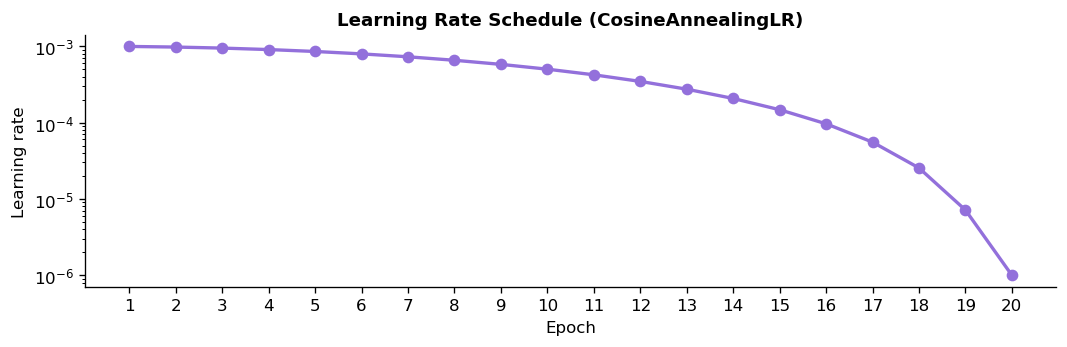

In [19]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(df['epoch'], df['lr'], 'o-', color='mediumpurple', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('Learning Rate Schedule (CosineAnnealingLR)')
ax.set_xticks(df['epoch'])
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Training speed

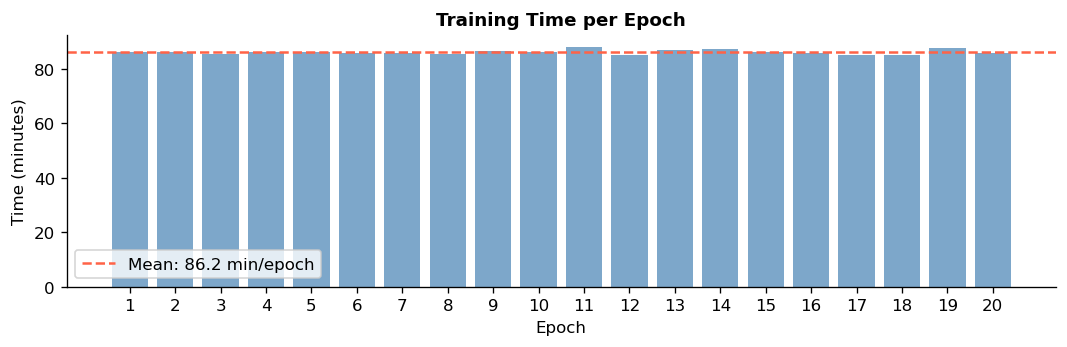

Total training time : 28.7 hours
Mean time per epoch : 86.2 minutes


In [20]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.bar(df['epoch'], df['time_s'] / 60, color='steelblue', alpha=0.7)
ax.axhline(df['time_s'].mean() / 60, color='tomato', linestyle='--',
           label=f"Mean: {df['time_s'].mean()/60:.1f} min/epoch")
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (minutes)')
ax.set_title('Training Time per Epoch')
ax.set_xticks(df['epoch'])
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_speed.png', dpi=150, bbox_inches='tight')
plt.show()

total_h = df['time_s'].sum() / 3600
print(f'Total training time : {total_h:.1f} hours')
print(f'Mean time per epoch : {df["time_s"].mean()/60:.1f} minutes')

## 7. Overfitting check — Train vs Val loss gap

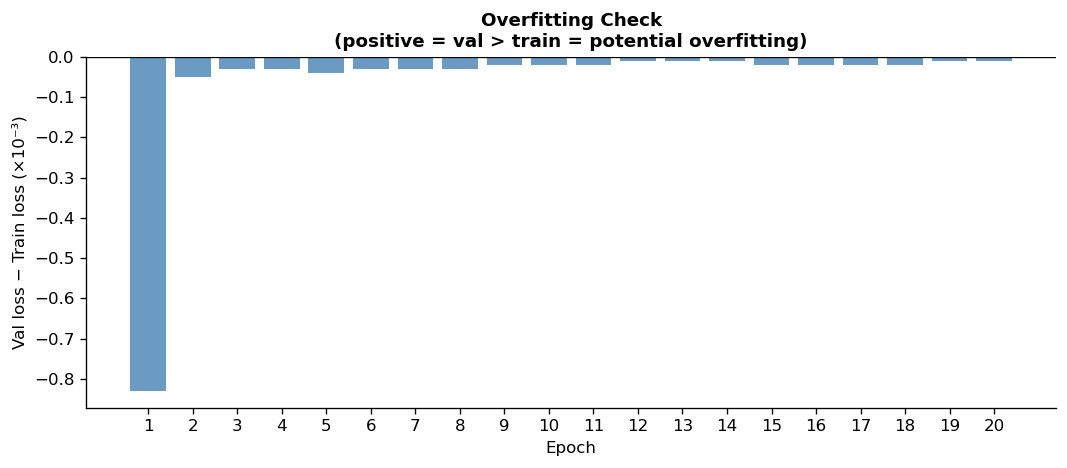

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))

gap = df['val_loss'] - df['train_loss']
ax.bar(df['epoch'], gap * 1000, color=[
    'tomato' if g > 0 else 'steelblue' for g in gap
], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val loss − Train loss (×10⁻³)')
ax.set_title('Overfitting Check\n(positive = val > train = potential overfitting)')
ax.set_xticks(df['epoch'])
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'overfitting_check.png', dpi=150, bbox_inches='tight')
plt.show()